# Investigating putative sectors 3 and 5

In [1]:
import os
import gzip
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

from mysca.constants import AA_COLORS
from mysca.constants import SECTOR_COLORS

In [2]:
SEED = None
if SEED is None or SEED == 0:
    SEED = np.random.randint(2**32)

print(f"seed: {SEED}")
rng = np.random.default_rng(seed=SEED)

seed: 267059280


In [3]:
DATDIRBASE = "../data/K00370"
RESDIRBASE = "../results/TIGR01580_with_soil_seqs_57"
fasta_fpath = f"{DATDIRBASE}/seqs/TIGR01580_with_soil_seqs_57.fasta"
msa_fpath = f"{DATDIRBASE}/msas/MSA_TIGR01580_with_soil_seqs_57.aln-fasta"

In [4]:
OUTDIR = "./out/putative_sectors_35"
IMGDIR = os.path.join(OUTDIR, "images")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(IMGDIR, exist_ok=True)

In [5]:
scadir = os.path.join(RESDIRBASE, "sca_results")

In [6]:
msa_fpath = f"{scadir}/msa.npy"
msa = np.load(msa_fpath)
print(f"Loaded MSA of shape {msa.shape}")

sca_matrix_fpath = f"{scadir}/sca_matrix.npy"
sca_matrix = np.load(sca_matrix_fpath)
print(f"Loaded SCA matrix of shape {sca_matrix.shape}")

retained_sequences_fpath = f"{scadir}/retained_sequences.npy"
retained_sequences = np.load(retained_sequences_fpath)
print(f"Loaded {retained_sequences.shape} retained sequence indices")

retained_positions_fpath = f"{scadir}/retained_positions.npy"
retained_positions = np.load(retained_positions_fpath)
print(f"Loaded {retained_positions.shape} retained position indices")

retained_sequence_ids_fpath = f"{scadir}/retained_sequence_ids.npy"
retained_sequence_ids = np.load(retained_sequence_ids_fpath)
print(f"Loaded {retained_sequences.shape} retained sequence IDs")

sequence_weights_fpath = f"{scadir}/sequence_weights.npy"
sequence_weights = np.load(sequence_weights_fpath)
print(f"Loaded {sequence_weights.shape} sequence weights")

Loaded MSA of shape (9307, 1111)
Loaded SCA matrix of shape (1111, 1111)
Loaded (9307,) retained sequence indices
Loaded (1111,) retained position indices
Loaded (9307,) retained sequence IDs
Loaded (9307,) sequence weights


In [7]:
fia = np.load(f"{scadir}/fia.npy")
phi_ia = np.load(f"{scadir}/phi_ia.npy")
Xmsa = scipy.sparse.load_npz(f"{scadir}/Xsp.npz").toarray()
W_ica = np.load(f"{scadir}/w_ica.npy")
evals_sca = np.load(f"{scadir}/significant_evals_sca.npy")
evecs_sca = np.load(f"{scadir}/significant_evecs_sca.npy")
Di = np.load(f"{scadir}/conservation.npy")

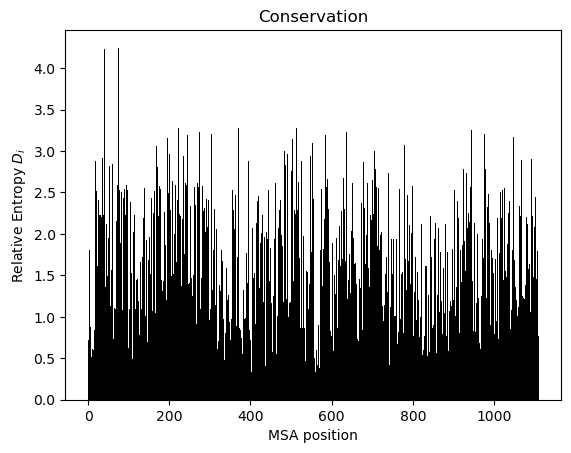

In [8]:
fig, ax = plt.subplots(1, 1)
ax.bar(range(len(Di)), Di, color='k', width=1.0, align="center")
ax.set_xlabel(f"MSA position")
ax.set_ylabel(f"Relative Entropy $D_i$")
ax.set_title(f"Conservation")

plt.show()

We need the MSA positional indices and scores corresponding to sectors 3 and 5. Let's load these now.

In [9]:
sector3_msaidxs = np.load(f"{scadir}/msa_sectors/sector_3_msapos.npy")
sector5_msaidxs = np.load(f"{scadir}/msa_sectors/sector_5_msapos.npy")
print(f"Loaded Sector3 MSA positions ({len(sector3_msaidxs)} indices)")
print(f"Loaded Sector5 MSA positions ({len(sector5_msaidxs)} indices)")

sector3_scores = np.load(f"{scadir}/msa_sectors/sector_3_scores.npy")
sector5_scores = np.load(f"{scadir}/msa_sectors/sector_5_scores.npy")
print(f"Loaded Sector3 MSA scores ({len(sector3_scores)} indices)")
print(f"Loaded Sector5 MSA scores ({len(sector5_scores)} indices)")

sector3_order = np.argsort(sector3_msaidxs)
sector5_order = np.argsort(sector5_msaidxs)

sector3_msaidxs = sector3_msaidxs[sector3_order]
sector5_msaidxs = sector5_msaidxs[sector5_order]
sector3_scores = sector3_scores[sector3_order]
sector5_scores = sector5_scores[sector5_order]


print(f"Sector3 MSA positions:\n{sector3_msaidxs}")
print(f"Sector5 MSA positions:\n{sector5_msaidxs}")

Loaded Sector3 MSA positions (91 indices)
Loaded Sector5 MSA positions (73 indices)
Loaded Sector3 MSA scores (91 indices)
Loaded Sector5 MSA scores (73 indices)
Sector3 MSA positions:
[  2  12  18  19  21  22  24  25  26  27  28  29  31  32  33  34  35  36
  37  38  39  40  41  42  46  47  49  52  53  54  55  56  57  59  60  61
  65  66  68  71  72  73  74  75  77  78  79  82  83  84  86  87  90  93
  94  96  97 100 101 103 106 107 111 112 114 115 117 119 121 124 128 132
 133 135 136 139 142 143 151 156 158 160 161 162 163 164 167 168 171 172
 173]
Sector5 MSA positions:
[ 934  935  936  937  944  952  953  960  975  977  979  980  982  983
  986  988  992  993  995  997  998  999 1003 1008 1009 1016 1017 1019
 1021 1024 1026 1027 1031 1032 1033 1035 1036 1038 1040 1042 1046 1048
 1049 1050 1054 1056 1057 1059 1063 1064 1065 1067 1068 1069 1071 1072
 1076 1077 1082 1083 1084 1086 1087 1088 1089 1091 1092 1093 1095 1098
 1101 1102 1108]


We now want to examine our variants with respect to these positions.

In [10]:
soilseqids_fpath = f"{DATDIRBASE}/misc/seqids_57.txt"
soilseqids = np.loadtxt(soilseqids_fpath, dtype=str)

In [11]:
sample_idxs = np.where(np.isin(retained_sequence_ids, soilseqids))[0]
soilseqs_msa = msa[sample_idxs,:]
soilseqs_msa_sector3 = soilseqs_msa[:,sector3_msaidxs]
soilseqs_msa_sector5 = soilseqs_msa[:,sector5_msaidxs]

external_idxs = np.where(~np.isin(retained_sequence_ids, soilseqids))[0]
external_msa = msa[external_idxs,:]
external_msa_sector3 = external_msa[:,sector3_msaidxs]
external_msa_sector5 = external_msa[:,sector5_msaidxs]

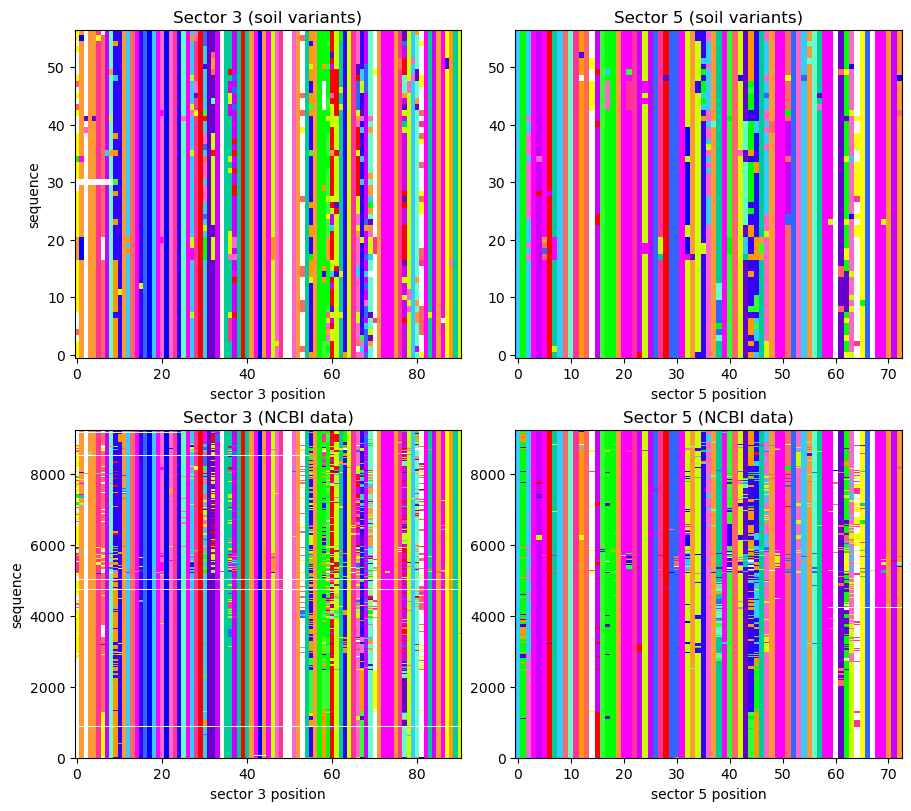

In [12]:
aa_list = list(AA_COLORS.keys())
color_list = [AA_COLORS[aa] for aa in aa_list]
cmap = ListedColormap(color_list)
norm = BoundaryNorm(np.arange(len(aa_list)+1)-0.5, cmap.N)


fig, axes = plt.subplots(2, 2, figsize=(9, 8), layout="constrained")

ax = axes[0][0]
ax.imshow(
    soilseqs_msa_sector3, 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=cmap, norm=norm,
)
ax.set_xlabel(f"sector 3 position")
ax.set_ylabel(f"sequence")
ax.set_title(f"Sector 3 (soil variants)")

ax = axes[0][1]
ax.imshow(
    soilseqs_msa_sector5, 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=cmap, norm=norm,
)
ax.set_xlabel(f"sector 5 position")
ax.set_title(f"Sector 5 (soil variants)")


ax = axes[1][0]
ax.imshow(
    external_msa_sector3, 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=cmap, norm=norm,
)
ax.set_xlabel(f"sector 3 position")
ax.set_ylabel(f"sequence")
ax.set_title(f"Sector 3 (NCBI data)")

ax = axes[1][1]
ax.imshow(
    external_msa_sector5, 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=cmap, norm=norm,
)
ax.set_xlabel(f"sector 5 position")
ax.set_title(f"Sector 5 (NCBI data)")


plt.show()

Question: How does the MSA compare to the value of the IC loading for that sector?

In [13]:
# Compute projection matrix
naas = fia.shape[1]
Xmsa = Xmsa.reshape([Xmsa.shape[0], -1, naas])
Pia = phi_ia * fia / np.sqrt(np.sum(np.square(phi_ia * fia)))
Xsi = np.sum(Pia[None,:,:] * Xmsa, axis=-1)
Utilde = Xsi @ evecs_sca / np.sqrt(evals_sca)
Up = Utilde @ W_ica.T

In [14]:
soilseqs_Up3 = Up[sample_idxs,3]
soilseqs_Up5 = Up[sample_idxs,5]
soilseq_sector3_order = np.argsort(soilseqs_Up3)
soilseq_sector5_order = np.argsort(soilseqs_Up5)

external_seq_Up3 = Up[external_idxs,3]
external_seq_Up5 = Up[external_idxs,5]
external_sector3_order = np.argsort(external_seq_Up3)
external_sector5_order = np.argsort(external_seq_Up5)

In [15]:
SECTOR3_COL = SECTOR_COLORS[3]
SECTOR5_COL = SECTOR_COLORS[5]

SECTOR3_CMAP = LinearSegmentedColormap.from_list(
    "grey2sect3", ["#888888", SECTOR3_COL]
)
SECTOR5_CMAP = LinearSegmentedColormap.from_list(
    "grey2sect5", ["#888888", SECTOR5_COL]
)

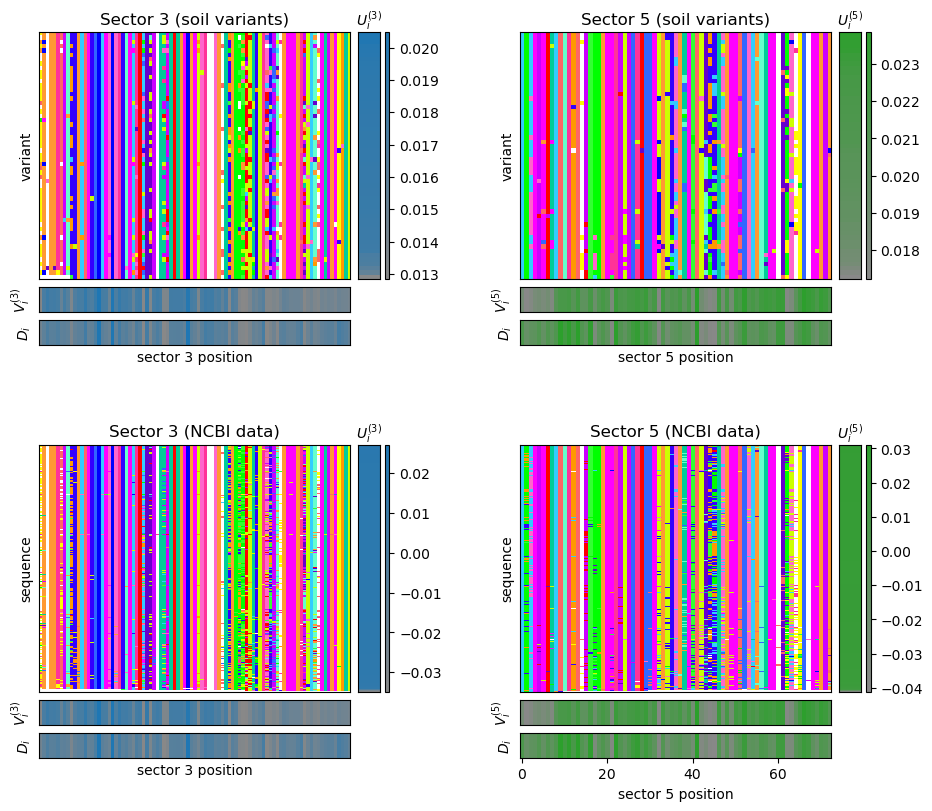

In [16]:

fig = plt.figure(figsize=(9, 8), layout="constrained")
gs = fig.add_gridspec(
    7, 7, 
    height_ratios=[10, 1, 1, 2, 10, 1, 1], hspace=0.01,
    width_ratios=[10, 1, 1, 2, 10, 1, 1], wspace=0.01,
)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Sector 3, Soil Variants
ridx, cidx = 0, 0
ax = fig.add_subplot(gs[ridx, cidx])
ax.imshow(
    soilseqs_msa_sector3[soilseq_sector3_order], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=cmap, 
    norm=norm,
)
ax.set_title(f"Sector 3 (soil variants)")
ax.set_ylabel(f"variant")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx, cidx+1])  # Row annotation
sc = ax.imshow(
    soilseqs_Up3[soilseq_sector3_order,None], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR3_CMAP,
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="20%", pad=0.05)
cbar = fig.colorbar(sc, cax=cax)
ax.set_xticks([])
ax.set_xlabel("$U_i^{{(3)}}$")
ax.xaxis.set_label_position("top")
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx+1, cidx])  # Column annotation
ax.imshow(
    sector3_scores[None,:], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR3_CMAP,
)
ax.set_ylabel("$V_i^{{(3)}}$")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx+2, cidx])  # Column annotation 2
ax.imshow(
    Di[sector3_msaidxs][None,:], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR3_CMAP,
)
ax.set_xlabel(f"sector 3 position")
ax.set_ylabel("$D_i$")
ax.set_xticks([])
ax.set_yticks([])

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Sector 5, Soil Variants
ridx, cidx = 0, 4
ax = fig.add_subplot(gs[ridx, cidx])
ax.imshow(
    soilseqs_msa_sector5[soilseq_sector5_order], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=cmap, 
    norm=norm,
)
ax.set_title(f"Sector 5 (soil variants)")
ax.set_ylabel(f"variant")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx, cidx+1])  # Row annotation
sc = ax.imshow(
    soilseqs_Up5[soilseq_sector5_order,None], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR5_CMAP,
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="20%", pad=0.05)
cbar = fig.colorbar(sc, cax=cax)
ax.set_xlabel("$U_i^{{(5)}}$")
ax.xaxis.set_label_position("top")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx+1, cidx])  # Column annotation
ax.imshow(
    sector5_scores[None,:], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR5_CMAP,
)
ax.set_ylabel("$V_i^{{(5)}}$")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx+2, cidx])  # Column annotation 2
ax.imshow(
    Di[sector5_msaidxs][None,:], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR5_CMAP,
)
ax.set_xlabel(f"sector 5 position")
ax.set_ylabel("$D_i$")
ax.set_xticks([])
ax.set_yticks([])


#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Sector 3, External Data
ridx, cidx = 4, 0
ax = fig.add_subplot(gs[ridx, cidx])
ax.imshow(
    external_msa_sector3[external_sector3_order], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=cmap, 
    norm=norm,
)
# ax.set_xlabel(f"sector 3 position")
ax.set_title(f"Sector 3 (NCBI data)")
ax.set_ylabel(f"sequence")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx, cidx+1])  # Row annotation
sc = ax.imshow(
    external_seq_Up3[external_sector3_order,None], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR3_CMAP,
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="20%", pad=0.05)
cbar = fig.colorbar(sc, cax=cax)
ax.set_xlabel("$U_i^{{(3)}}$")
ax.xaxis.set_label_position("top")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx+1, cidx])  # Column annotation
ax.imshow(
    sector3_scores[None,:], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR3_CMAP,
)
ax.set_ylabel("$V_i^{{(3)}}$")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx+2, cidx])  # Column annotation 2
ax.imshow(
    Di[sector3_msaidxs][None,:], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR3_CMAP,
)
ax.set_xlabel(f"sector 3 position")
ax.set_ylabel("$D_i$")
ax.set_xticks([])
ax.set_yticks([])

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Sector 5, External Data
ridx, cidx = 4, 4
ax = fig.add_subplot(gs[ridx, cidx])
ax.imshow(
    external_msa_sector5[external_sector5_order], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=cmap, 
    norm=norm,
)
ax.set_title(f"Sector 5 (NCBI data)")
ax.set_ylabel(f"sequence")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx, cidx+1])  # Row annotation
sc = ax.imshow(
    external_seq_Up5[external_sector5_order,None], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR5_CMAP,
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="20%", pad=0.05)
cbar = fig.colorbar(sc, cax=cax)
ax.set_xlabel("$U_i^{{(5)}}$")
ax.xaxis.set_label_position("top")
ax.set_xticks([])
ax.set_yticks([])


ax = fig.add_subplot(gs[ridx+1, cidx])  # Column annotation
ax.imshow(
    sector5_scores[None,:], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR5_CMAP,
)
ax.set_ylabel("$V_i^{{(5)}}$")
ax.set_xticks([])
ax.set_yticks([])

ax = fig.add_subplot(gs[ridx+2, cidx])  # Column annotation 2
ax.imshow(
    Di[sector5_msaidxs][None,:], 
    origin="lower",
    aspect="auto", interpolation="None",
    cmap=SECTOR5_CMAP,
)
ax.set_xlabel(f"sector 5 position")
ax.set_ylabel("$D_i$")
ax.set_yticks([])

plt.show()

It appears that the small number of external sequences that have relatively large negative values of $U_i^{(k)}$ for $k=3$ and $k=5$ may be what leads to the identification of the two contiguous sectors. Let's identify these positions. This will allow us to construct a new sequence set with these sequences removed. 

U3 threshold: 0.015


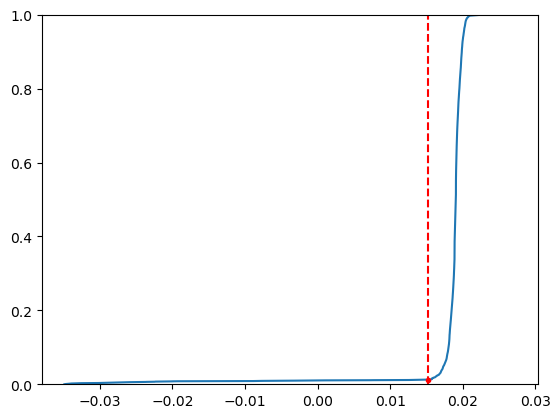

In [17]:
# Threshold for Sector 3

thresh_U3 = 0.015

fig, ax = plt.subplots(1, 1)
x = np.sort(external_seq_Up3)
y = np.arange(1, len(x) + 1) / len(x)
ax.plot(x, y)

idx = np.where(x >= thresh_U3)[0][0]

ax.axvline(x[idx], linestyle="--", color="r")
ax.plot(x[idx], y[idx], 'r.')
ax.set_ylim(0, 1)

print("U3 threshold:", thresh_U3)

plt.show()

U5 threshold: 0.015


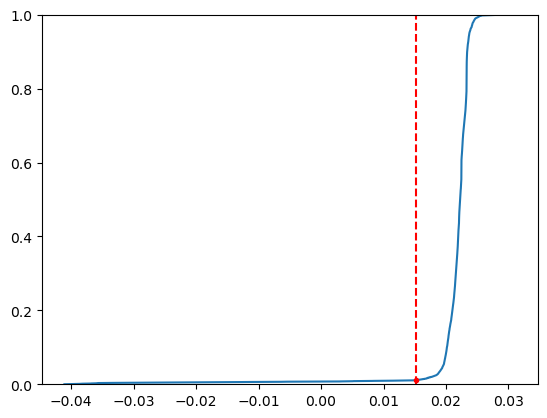

In [18]:
# Threshold for Sector 5

thresh_U5 = 0.015

fig, ax = plt.subplots(1, 1)
x = np.sort(external_seq_Up5)
y = np.arange(1, len(x) + 1) / len(x)
ax.plot(x, y)

idx = np.where(x >= thresh_U5)[0][0]

ax.axvline(x[idx], linestyle="--", color="r")
ax.plot(x[idx], y[idx], 'r.')
ax.set_ylim(0, 1)

print("U5 threshold:", thresh_U5)

plt.show()

In [19]:
idxs_U3_exceeders_external = external_idxs[np.where(external_seq_Up3 < thresh_U3)[0]]
idxs_U5_exceeders_external = external_idxs[np.where(external_seq_Up5 < thresh_U5)[0]]

print(idxs_U3_exceeders_external)
print(idxs_U5_exceeders_external)

[  96  107  108  818  884  885  886  927 1221 1241 1289 1305 1311 2439
 2471 2472 2473 2474 2475 2476 2483 2502 2504 2527 2782 2982 3204 3476
 3477 3680 3684 3688 3760 3993 3999 4000 4226 4241 4242 4610 4611 4612
 4613 4621 4646 4673 4747 4950 4984 4986 4988 4996 5032 5042 5047 5104
 5234 5240 5244 5291 5314 5320 5324 5331 5337 5341 5388 5419 5493 5521
 5589 5788 5789 5790 5811 5812 5813 5814 5943 5998 6006 6250 6518 6811
 6820 6993 7000 7083 7110 7111 7192 7254 7608 7626 7656 7657 7803 7886
 7936 7937 7940 7972 8038 8059 8137 8166 8197 8547 8567 8725 8729 8848
 8884 9208 9255 9286]
[   1    2    4   87   90  113  819  887  888  889  890  981 1295 1301
 1302 1303 1304 1310 2766 3348 3350 3640 3686 3763 3944 3998 4160 4165
 4188 4234 4253 4254 4618 4620 4735 4939 4950 4964 4980 4984 4994 4997
 5000 5096 5211 5215 5223 5224 5235 5256 5257 5259 5314 5323 5328 5379
 5454 5462 5463 5480 5482 5541 5553 5596 5630 5652 5743 5789 5790 5812
 5813 5814 5841 5857 5904 5925 5945 6146 6350 6351 6412

In [28]:
seqidxs_to_remove = np.unique(np.sort(np.concatenate(
    [idxs_U3_exceeders_external, idxs_U5_exceeders_external]
)))

seqids_to_remove = retained_sequence_ids[seqidxs_to_remove]

np.savetxt(f"{OUTDIR}/sector35_exceeders.txt", seqids_to_remove, fmt="%s")

In [29]:
len(seqids_to_remove)

205

In [36]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

print(len(list(SeqIO.parse(fasta_fpath, "fasta"))))

records = SeqIO.parse(fasta_fpath, "fasta")
records_out = [
    rec for rec in records if not np.isin(rec.id, seqids_to_remove)
]
print(len(records_out) + len(seqids_to_remove))

SeqIO.write(records_out, f"{OUTDIR}/TIGR01580_filter_ic35_with_soil_seqs_57.fasta", "fasta")

9614
9614


9409

9614


In [17]:
# n = 300
# for i in range(len(Di) // n + int(len(Di) % n != 0)):
#     fig, ax = plt.subplots(1, 1)
#     start = n * i
#     stop = min(n * (i+1), len(Di))
#     subset = Di[start:stop]
#     ax.bar(range(start, stop), subset, color='k', width=1.0, align="center")
#     ax.set_xlabel(f"MSA position")
#     ax.set_ylabel(f"Relative Entropy $D_i$")
#     ax.set_title(f"Conservation")

In [18]:
# Load the matrix Cijab_raw and phi_ia, in order to compute Cijab

Cijab_raw = np.load(gzip.GzipFile(f"{scadir}/Cijab_raw.npy.gz", "r"))
Cijab = phi_ia[:,None,:,None] * phi_ia[None,:,None,:] * Cijab_raw

del Cijab_raw